In [1]:
!pip install transformers datasets accelerate

In [2]:
# import libraries
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
zip_path = "archive.zip"   # change if your zip file name is different
extract_path = "dataset_folder"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")
print("Files inside folder:")
print(os.listdir(extract_path))

ZIP extracted successfully!
Files inside folder:
['IMDB Dataset.csv']


In [6]:
# load dataset
csv_path = os.path.join(extract_path, "IMDB Dataset.csv")
df = pd.read_csv(csv_path)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Take only 10,000 rows to make training lighter and faster
df = df.sample(n=10000, random_state=42).reset_index(drop=True)

print("New dataset shape:", df.shape)

New dataset shape: (10000, 2)


In [8]:
# check data
print(df.shape)
print(df.isnull().sum())
print(df['sentiment'].value_counts())

(10000, 2)
review       0
sentiment    0
dtype: int64
sentiment
positive    5039
negative    4961
Name: count, dtype: int64


In [9]:
# clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review'] = df['review'].apply(clean_text)

print("Cleaning completed!")

Cleaning completed!


In [10]:
# remove missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Missing values handled!")
print(df.shape)

Missing values handled!
(10000, 2)


In [11]:
# encode lables
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(label, "->", i)

Label mapping:
negative -> 0
positive -> 1


In [12]:
# split data
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 8000
Validation: 1000
Test: 1000


In [13]:
# load tokenizer
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

print("Tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded!


In [14]:
# convert to dataset format
train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
val_df = pd.DataFrame({"text": val_texts, "label": val_labels})
test_df = pd.DataFrame({"text": test_texts, "label": test_labels})

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [15]:
# tokenization
def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding=False, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenization done!")

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization done!


In [16]:
# metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average='weighted'),
        "recall": recall_score(labels, preds, average='weighted'),
        "f1": f1_score(labels, preds, average='weighted')
    }

In [17]:
# load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2
)

print("Model loaded successfully!")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [18]:
# training settings
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none"
)

In [19]:
# train model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.472663,0.502676,0.860000,0.860065,0.860000,0.860002


TrainOutput(global_step=2000, training_loss=0.4897299118041992, metrics={'train_runtime': 250.6056, 'train_samples_per_second': 31.923, 'train_steps_per_second': 7.981, 'total_flos': 526168666286880.0, 'train_loss': 0.4897299118041992, 'epoch': 1.0})

In [20]:
# evaluate model
results = trainer.evaluate(test_dataset)
print("Test Results:")
print(results)

Test Results:
{'eval_loss': 0.4374241530895233, 'eval_accuracy': 0.874, 'eval_precision': 0.874639374719713, 'eval_recall': 0.874, 'eval_f1': 0.8739697556448128, 'eval_runtime': 8.4906, 'eval_samples_per_second': 117.777, 'eval_steps_per_second': 29.444, 'epoch': 1.0}


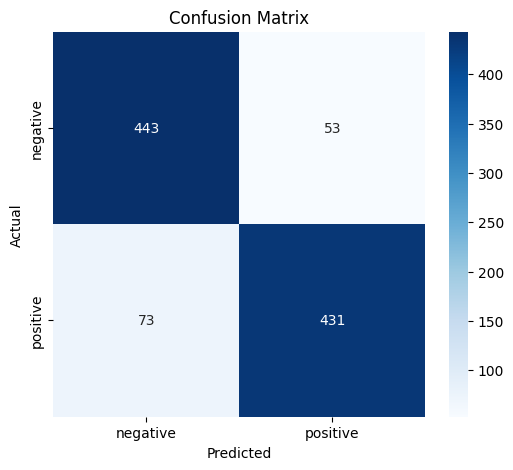

In [21]:
# confusion matrix
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
# classification report
print(classification_report(labels, preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    negative       0.86      0.89      0.88       496
    positive       0.89      0.86      0.87       504

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



In [23]:
# save results
results_df = pd.DataFrame([results])
results_df.to_csv("bert_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!
